In [3]:
!pip install sentence-transformers


,Requirement already satisfied: transformers<6.0.0,>=4.41.0 in /usr/local/lib/python3.12/dist-packages (from sentence-transformers) (5.0.0)
,Requirement already satisfied: huggingface-hub>=0.20.0 in /usr/local/lib/python3.12/dist-packages (from sentence-transformers) (1.7.1)
,Requirement already satisfied: torch>=1.11.0 in /usr/local/lib/python3.12/dist-packages (from sentence-transformers) (2.10.0+cpu)
,Requirement already satisfied: numpy in /usr/local/lib/python3.12/dist-packages (from sentence-transformers) (2.0.2)
,Requirement already satisfied: scikit-learn in /usr/local/lib/python3.12/dist-packages (from sentence-transformers) (1.6.1)
,Requirement already satisfied: scipy in /usr/local/lib/python3.12/dist-packages (from sentence-transformers) (1.16.3)
,Requirement already satisfied: typing_extensions>=4.5.0 in /usr/local/lib/python3.12/dist-packages (from sentence-transformers) (4.15.0)
,Requirement already satisfied: tqdm in /usr/local/lib/python3.12/dist-packages (from sentenc

In [5]:
from sentence_transformers import SentenceTransformer
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns
import matplotlib.pyplot as plt

In [6]:
sentences = [
    # Cricket sentences (4 sentences)
    "The batsman hit a magnificent six over the boundary",
    "The spinner bowled a perfect googly that deceived the batsman",
    "The fielder took a spectacular diving catch at the boundary",
    "The captain won the toss and decided to bat first",

    # Cooking sentences (3 sentences)
    "Sauté the onions until they turn golden brown",
    "Add fresh herbs and spices to enhance the flavor",
    "Preheat the oven to 180 degrees Celsius before baking",

    # Cybersecurity sentences (3 sentences)
    "Two-factor authentication adds an extra layer of security",
    "Encrypt sensitive data before storing it in the database",
    "Regular security patches help protect against vulnerabilities"
]

In [7]:
print("=" * 60)
print("SENTENCES BY TOPIC")
print("=" * 60)
for i, sentence in enumerate(sentences, 1):
    if i <= 4:
        topic = "Cricket"
    elif i <= 7:
        topic = "Cooking"
    else:
        topic = "Cybersecurity"
    print(f"{i}. [{topic}] {sentence}")
print()

,SENTENCES BY TOPIC
,============================================================
,1. [Cricket] The batsman hit a magnificent six over the boundary
,2. [Cricket] The spinner bowled a perfect googly that deceived the batsman
,3. [Cricket] The fielder took a spectacular diving catch at the boundary
,4. [Cricket] The captain won the toss and decided to bat first
,5. [Cooking] Sauté the onions until they turn golden brown
,6. [Cooking] Add fresh herbs and spices to enhance the flavor
,7. [Cooking] Preheat the oven to 180 degrees Celsius before baking
,8. [Cybersecurity] Two-factor authentication adds an extra layer of security
,9. [Cybersecurity] Encrypt sensitive data before storing it in the database
,10. [Cybersecurity] Regular security patches help protect against vulnerabilities
,


In [8]:
print("=" * 60)
print("LOADING MODEL AND GENERATING EMBEDDINGS")
print("=" * 60)
model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model.encode(sentences)
print(f"Model loaded: all-MiniLM-L6-v2")
print(f"Number of sentences: {len(sentences)}")
print(f"Embedding dimension: {embeddings.shape[1]}")
print(f"Embeddings shape: {embeddings.shape}")
print()

,LOADING MODEL AND GENERATING EMBEDDINGS
,============================================================


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
,The secret `HF_TOKEN` does not exist in your Colab secrets.
,To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
,You will be able to reuse this secret in all of your notebooks.
,Please note that authentication is recommended but still optional to access public models or datasets.
,  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Model loaded: all-MiniLM-L6-v2
,Number of sentences: 10
,Embedding dimension: 384
,Embeddings shape: (10, 384)
,


,COMPUTING 10×10 COSINE SIMILARITY MATRIX
,============================================================
,Similarity matrix computed successfully
,Matrix shape: (10, 10)
,
,Cosine Similarity Matrix:
,[[ 1.     0.468  0.428  0.436  0.057  0.051 -0.006  0.    -0.032  0.044]
, [ 0.468  1.     0.341  0.454  0.167  0.06   0.016  0.029  0.018  0.007]
, [ 0.428  0.341  1.     0.413 -0.01   0.011 -0.069  0.007 -0.038  0.029]
, [ 0.436  0.454  0.413  1.     0.033 -0.016  0.076 -0.013 -0.031 -0.083]
, [ 0.057  0.167 -0.01   0.033  1.     0.23   0.218 -0.042  0.092  0.002]
, [ 0.051  0.06   0.011 -0.016  0.23   1.    -0.009  0.04   0.031  0.057]
, [-0.006  0.016 -0.069  0.076  0.218 -0.009  1.    -0.038  0.206 -0.008]
, [ 0.     0.029  0.007 -0.013 -0.042  0.04  -0.038  1.     0.122  0.25 ]
, [-0.032  0.018 -0.038 -0.031  0.092  0.031  0.206  0.122  1.     0.129]
, [ 0.044  0.007  0.029 -0.083  0.002  0.057 -0.008  0.25   0.129  1.   ]]
,
,==========================================================

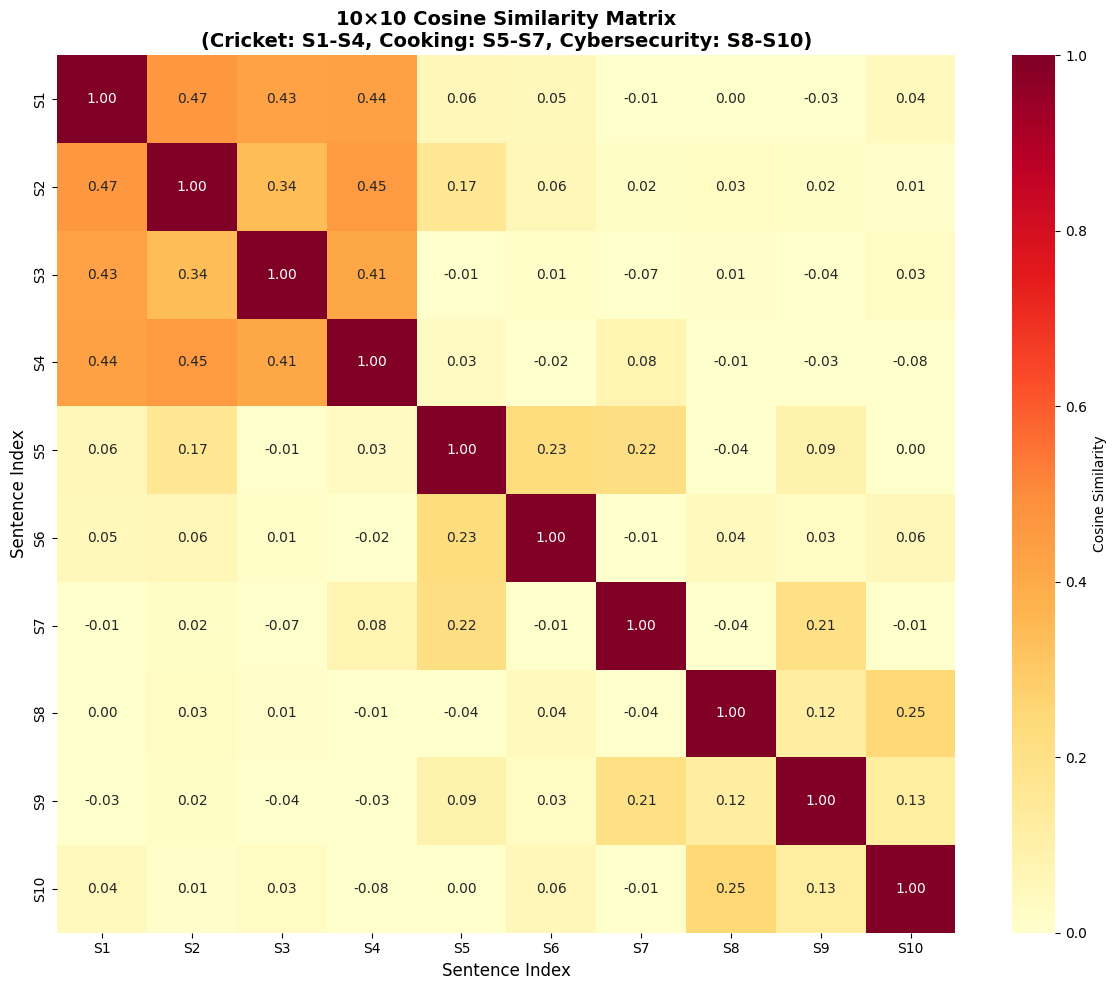

Heatmap created successfully
,
,============================================================
,QUERY SIMILARITY SEARCH
,============================================================
,Query: 'The bowler took three wickets in one over'
,


In [11]:
print("=" * 60)
print("COMPUTING 10×10 COSINE SIMILARITY MATRIX")
print("=" * 60)
similarity_matrix = cosine_similarity(embeddings)
print("Similarity matrix computed successfully")
print(f"Matrix shape: {similarity_matrix.shape}")
print()
print("Cosine Similarity Matrix:")
print(np.round(similarity_matrix, 3))
print()

# Cell 6: Create Heatmap Visualization
print("=" * 60)
print("CREATING HEATMAP VISUALIZATION")
print("=" * 60)
plt.figure(figsize=(12, 10))
sns.heatmap(similarity_matrix,
            annot=True,
            fmt='.2f',
            cmap='YlOrRd',
            xticklabels=[f"S{i+1}" for i in range(10)],
            yticklabels=[f"S{i+1}" for i in range(10)],
            cbar_kws={'label': 'Cosine Similarity'},
            vmin=0,
            vmax=1)
plt.title('10×10 Cosine Similarity Matrix\n(Cricket: S1-S4, Cooking: S5-S7, Cybersecurity: S8-S10)',
          fontsize=14,
          fontweight='bold')
plt.xlabel('Sentence Index', fontsize=12)
plt.ylabel('Sentence Index', fontsize=12)
plt.tight_layout()
plt.show()
print("Heatmap created successfully")
print()

# Cell 7: Query Similarity Search
print("=" * 60)
print("QUERY SIMILARITY SEARCH")
print("=" * 60)
query = "The bowler took three wickets in one over"
print(f"Query: '{query}'")
print()

In [12]:
query_embedding = model.encode([query])


In [13]:
query_similarities = cosine_similarity(query_embedding, embeddings)[0]


In [14]:
top_2_indices = np.argsort(query_similarities)[-2:][::-1]


In [15]:
print("TOP 2 MOST SIMILAR SENTENCES:")
print("-" * 60)
for rank, idx in enumerate(top_2_indices, 1):
    similarity_score = query_similarities[idx]
    print(f"Rank {rank}:")
    print(f"  Sentence {idx+1}: {sentences[idx]}")
    print(f"  Similarity Score: {similarity_score:.4f}")
    print()

TOP 2 MOST SIMILAR SENTENCES:
,------------------------------------------------------------
,Rank 1:
,  Sentence 2: The spinner bowled a perfect googly that deceived the batsman
,  Similarity Score: 0.5754
,
,Rank 2:
,  Sentence 1: The batsman hit a magnificent six over the boundary
,  Similarity Score: 0.5523
,


In [16]:
print("=" * 60)
print("ALL SIMILARITY SCORES (for reference)")
print("=" * 60)
for i, (sentence, score) in enumerate(zip(sentences, query_similarities), 1):
    print(f"S{i}: {score:.4f} - {sentence}")

,ALL SIMILARITY SCORES (for reference)
,============================================================
,S1: 0.5523 - The batsman hit a magnificent six over the boundary
,S2: 0.5754 - The spinner bowled a perfect googly that deceived the batsman
,S3: 0.3073 - The fielder took a spectacular diving catch at the boundary
,S4: 0.5202 - The captain won the toss and decided to bat first
,S5: 0.1595 - Sauté the onions until they turn golden brown
,S6: 0.0467 - Add fresh herbs and spices to enhance the flavor
,S7: -0.0063 - Preheat the oven to 180 degrees Celsius before baking
,S8: -0.0448 - Two-factor authentication adds an extra layer of security
,S9: -0.0663 - Encrypt sensitive data before storing it in the database
,S10: -0.0448 - Regular security patches help protect against vulnerabilities
